In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from project.data_manager import DataManager

In [129]:
manager = DataManager()

In [130]:
flights = '../database/flights.csv'
wanted_cols = [
    'MONTH',
    'DAY_OF_WEEK',
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE',
    'DISTANCE',
    'SCHEDULED_ARRIVAL',
    'DELAYED',
    'FLIGHT_NUMBER',
    'SCHEDULED_TIME'
]

In [131]:
df = manager.create_flights_dataframe(delay_limit=15, csv_path=flights)

In [132]:
manager.show_stats(df)






col:  -------------------------- YEAR   nans:  0  unique values:  1
col:  ------------------------- MONTH   nans:  0  unique values:  12
col:  --------------------------- DAY   nans:  0  unique values:  31
col:  ------------------- DAY_OF_WEEK   nans:  0  unique values:  7
col:  ----------------------- AIRLINE   nans:  0  unique values:  14
col:  ----------------- FLIGHT_NUMBER   nans:  0  unique values:  6946
col:  ------------------- TAIL_NUMBER   nans:  0  unique values:  4896
col:  ---------------- ORIGIN_AIRPORT   nans:  0  unique values:  628
col:  ----------- DESTINATION_AIRPORT   nans:  0  unique values:  629
col:  ----------- SCHEDULED_DEPARTURE   nans:  0  unique values:  1320
col:  ---------------- DEPARTURE_TIME   nans:  0  unique values:  1440
col:  --------------- DEPARTURE_DELAY   nans:  0  unique values:  1212
col:  ---------------------- TAXI_OUT   nans:  0  unique values:  184
col:  -------------------- WHEELS_OFF   nans:  0  unique values:  1440
col:  ----------

In [150]:
filtered_df = manager.create_df_sample(df=df, percentage=2, wanted_cols=wanted_cols)

hours_to_transform = [
    'SCHEDULED_DEPARTURE',
    'SCHEDULED_ARRIVAL',
    'SCHEDULED_TIME'
]

for col in ['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
    filtered_df[col] = (
        filtered_df[col]
        .astype(str)
        .str.replace(r'\d+', '', regex=True)
        .str.strip()
    )

manager.hour_to_sec(df=filtered_df, cols=hours_to_transform)

filtered_df = manager.create_aux_features(filtered_df=filtered_df)

df_encoded = manager.encode_df(filtered_df)

manager.show_stats(df_encoded)






col:  ------------------------- MONTH   nans:  0  unique values:  12
col:  ------------------- DAY_OF_WEEK   nans:  0  unique values:  7
col:  ----------- SCHEDULED_DEPARTURE   nans:  0  unique values:  1234
col:  ---------------------- DISTANCE   nans:  0  unique values:  1304
col:  ------------- SCHEDULED_ARRIVAL   nans:  0  unique values:  1336
col:  ----------------------- DELAYED   nans:  0  unique values:  2
col:  ----------------- FLIGHT_NUMBER   nans:  0  unique values:  6383
col:  ---------------- SCHEDULED_TIME   nans:  0  unique values:  318
col:  ----------------------- HOLIDAY   nans:  0  unique values:  2
col:  ------------------- SEASON_FALL   nans:  0  unique values:  2
col:  ----------------- SEASON_SPRING   nans:  0  unique values:  2
col:  ----------------- SEASON_SUMMER   nans:  0  unique values:  2
col:  ----------------- SEASON_WINTER   nans:  0  unique values:  2
col:  -------------- PERIOD_AFTERNOON   nans:  0  unique values:  2
col:  ---------------- PERIO

C:\Users\Pedro\AppData\Local\Temp\ipykernel_10616\1845954055.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x='AIRLINE', y='DELAYED', data=atrasos_por_airline, palette='magma')


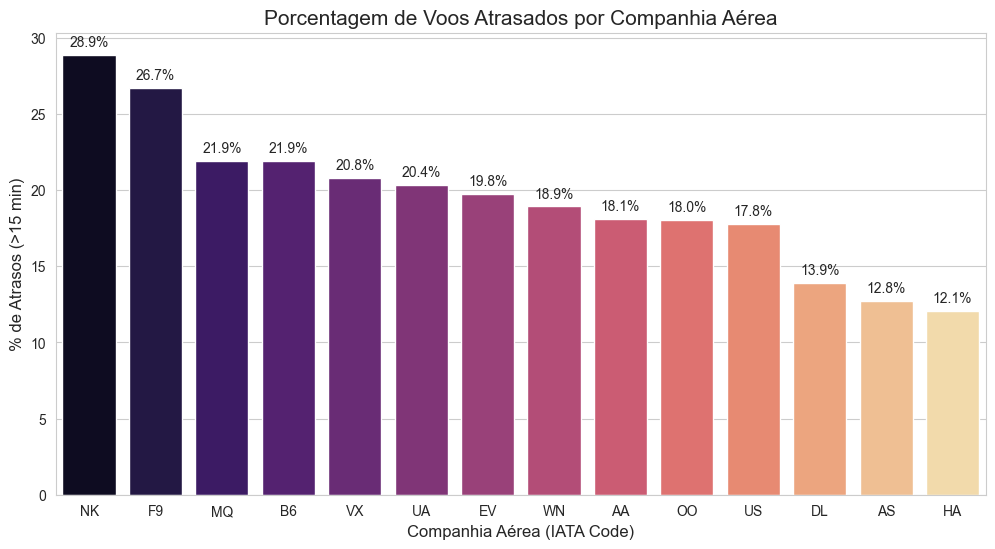

In [151]:
# 1. Agrupando os dados por companhia e calculando a média de atrasos
# Como a coluna 'DELAYED' é binária (0 ou 1), a média representa a proporção de atrasos.
atrasos_por_airline = filtered_df.groupby('AIRLINE')['DELAYED'].mean().reset_index()

# 2. Convertendo para porcentagem para facilitar a leitura
atrasos_por_airline['DELAYED'] = atrasos_por_airline['DELAYED'] * 100

# 3. Ordenando as empresas pelas que mais atrasam
atrasos_por_airline = atrasos_por_airline.sort_values(by='DELAYED', ascending=False)

# 4. Criando o gráfico de barras
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
plot = sns.barplot(x='AIRLINE', y='DELAYED', data=atrasos_por_airline, palette='magma')

# Adicionando rótulos e título
plt.title('Porcentagem de Voos Atrasados por Companhia Aérea', fontsize=15)
plt.xlabel('Companhia Aérea (IATA Code)', fontsize=12)
plt.ylabel('% de Atrasos (>15 min)', fontsize=12)

# Adicionando os valores em cima das barras para facilitar a análise descritiva
for p in plot.patches:
    plot.annotate(format(p.get_height(), '.1f') + '%', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.show()

C:\Users\Pedro\AppData\Local\Temp\ipykernel_10616\2108200585.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DAY_OF_WEEK', y='DELAYED', data=df_dow, ax=ax2, palette='viridis')
C:\Users\Pedro\AppData\Local\Temp\ipykernel_10616\2108200585.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])


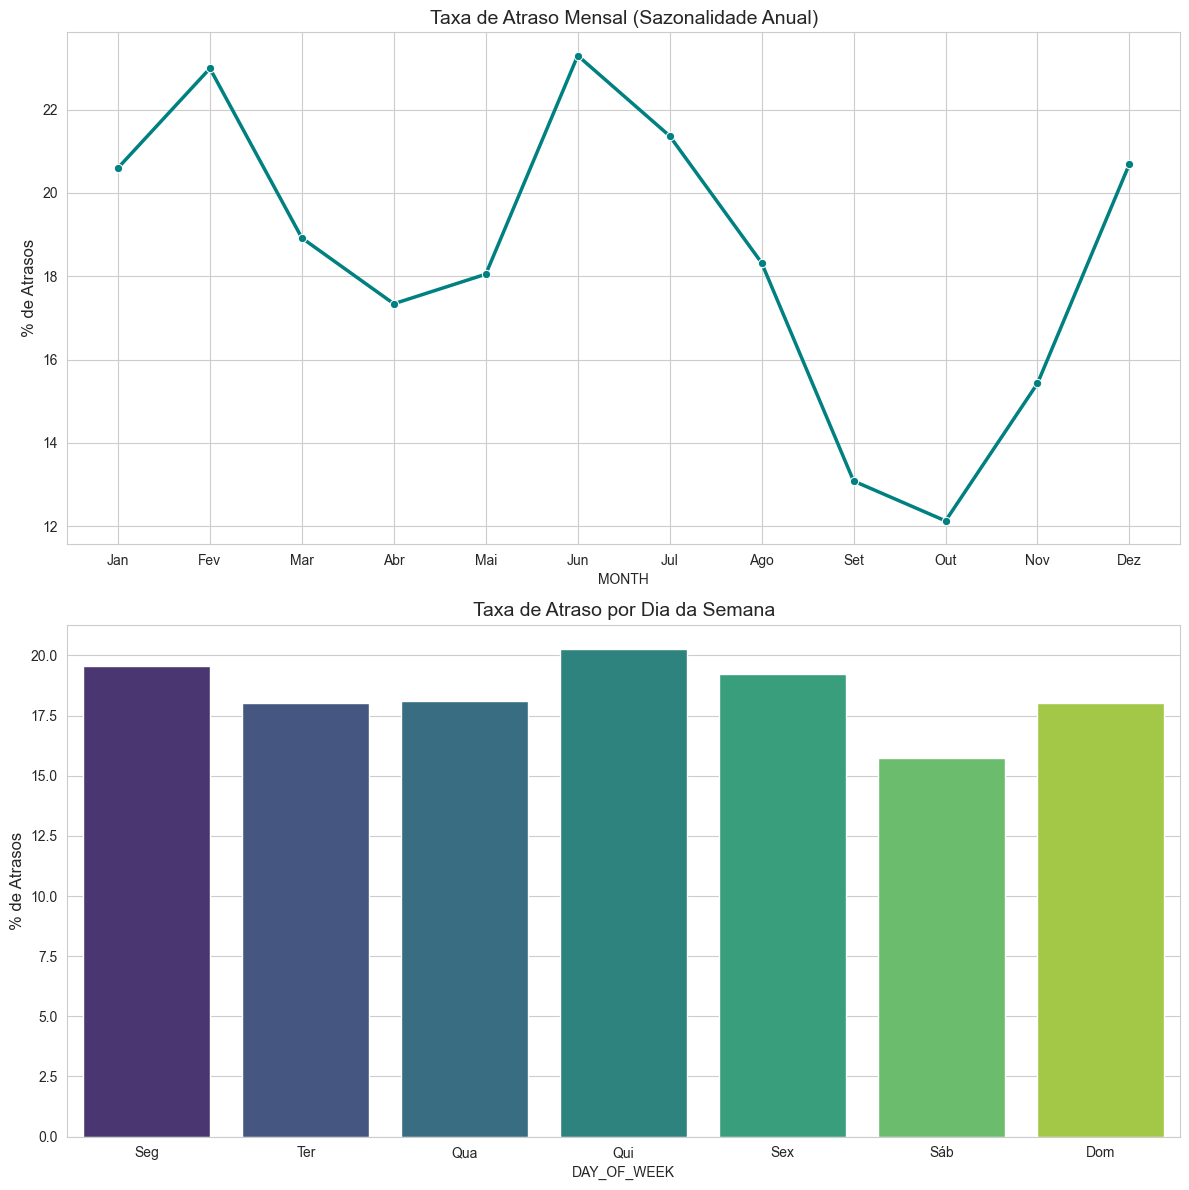

In [152]:
# Configuração visual geral
#sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- 1. Sazonalidade por Mês (MONTH) ---
# Calculando a proporção de atrasos por mês
df_month = filtered_df.groupby('MONTH')['DELAYED'].mean().reset_index()
df_month['DELAYED'] *= 100 # Converter para %

sns.lineplot(x='MONTH', y='DELAYED', data=df_month, marker='o', ax=ax1, color='teal', linewidth=2.5)
ax1.set_title('Taxa de Atraso Mensal (Sazonalidade Anual)', fontsize=14)
ax1.set_ylabel('% de Atrasos', fontsize=12)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# --- 2. Sazonalidade por Dia da Semana (DAY_OF_WEEK) ---
# Calculando a proporção de atrasos por dia da semana
df_dow = filtered_df.groupby('DAY_OF_WEEK')['DELAYED'].mean().reset_index()
df_dow['DELAYED'] *= 100 # Converter para %

sns.barplot(x='DAY_OF_WEEK', y='DELAYED', data=df_dow, ax=ax2, palette='viridis')
ax2.set_title('Taxa de Atraso por Dia da Semana', fontsize=14)
ax2.set_ylabel('% de Atrasos', fontsize=12)
ax2.set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])

# Ajuste de layout
plt.tight_layout()
plt.show()

In [153]:
# cols_to_keep = [
#                 'SCHEDULED_DEPARTURE', 
#                 'DELAYED', 
#                 'SEASON_FALL',
#                 'SEASON_SPRING',
#                 'SEASON_SUMMER',
#                 'SEASON_WINTER'
#                 ]

#BEST RESULTS
cols_to_keep = [
                'SEASON_WINTER',
                'SEASON_FALL',
                'SEASON_SUMMER',
                'SEASON_SPRING',
                'HOLIDAY',
                'MONTH',
                'PERIOD_MORNING',
                'SCHEDULED_DEPARTURE',
                'AIRLINE_COD',
                'DELAYED'
                ]

#cols_to_keep = df_encoded.columns

df_encoded = df_encoded[cols_to_keep]

[x_train, x_test, y_train, y_test] = manager.get_test_split(df=df_encoded, target='DELAYED')


C:\Users\Pedro\AppData\Local\Temp\ipykernel_10616\3756805508.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x='Estação', y='Taxa de Atraso (%)', data=df_sazonal, palette='coolwarm')


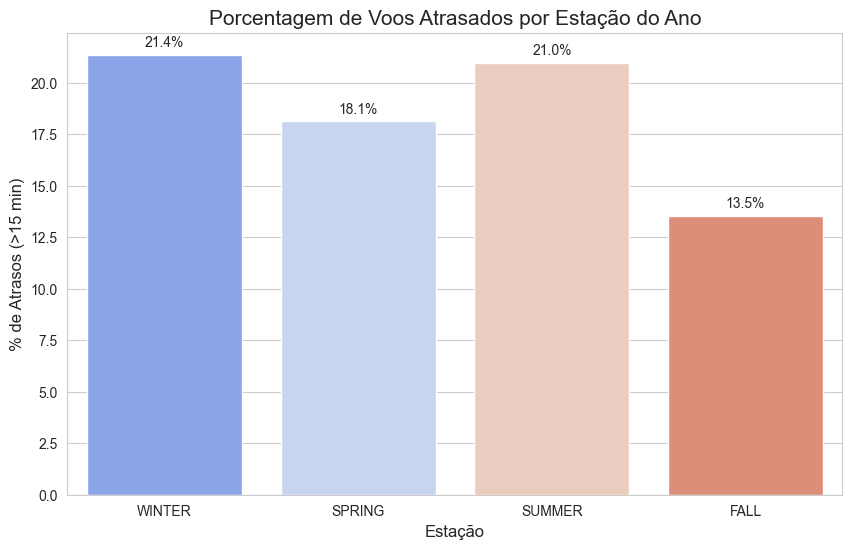

In [154]:
# 1. Definindo as colunas de estações que você criou no df_encoded
colunas_estacoes = ['SEASON_WINTER', 'SEASON_SPRING', 'SEASON_SUMMER', 'SEASON_FALL']

# 2. Calculando a porcentagem de atrasos para cada estação
# Filtramos onde a coluna da estação é 1 e tiramos a média do 'DELAYED'
dados_estacoes = []
for col in colunas_estacoes:
    porcentagem = df_encoded[df_encoded[col] == 1]['DELAYED'].mean() * 100
    dados_estacoes.append({'Estação': col.replace('SEASON_', ''), 'Taxa de Atraso (%)': porcentagem})

# 3. Transformando em DataFrame para o Seaborn
df_sazonal = pd.DataFrame(dados_estacoes)

# 4. Criando o gráfico de barras
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
plot = sns.barplot(x='Estação', y='Taxa de Atraso (%)', data=df_sazonal, palette='coolwarm')

# Adicionando rótulos e título
plt.title('Porcentagem de Voos Atrasados por Estação do Ano', fontsize=15)
plt.ylabel('% de Atrasos (>15 min)', fontsize=12)
plt.xlabel('Estação', fontsize=12)

# Adicionando os valores em cima das barras
for p in plot.patches:
    plot.annotate(format(p.get_height(), '.1f') + '%', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.show()

In [155]:
manager.show_stats(df_encoded)






col:  ----------------- SEASON_WINTER   nans:  0  unique values:  2
col:  ------------------- SEASON_FALL   nans:  0  unique values:  2
col:  ----------------- SEASON_SUMMER   nans:  0  unique values:  2
col:  ----------------- SEASON_SPRING   nans:  0  unique values:  2
col:  ----------------------- HOLIDAY   nans:  0  unique values:  2
col:  ------------------------- MONTH   nans:  0  unique values:  12
col:  ---------------- PERIOD_MORNING   nans:  0  unique values:  2
col:  ----------- SCHEDULED_DEPARTURE   nans:  0  unique values:  1234
col:  ------------------- AIRLINE_COD   nans:  0  unique values:  14
col:  ----------------------- DELAYED   nans:  0  unique values:  2





In [156]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)

#ONLY FOR TRAINING
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print(f"Antes do SMOTE: {Counter(y_train)}")
print(f"Depois do SMOTE: {Counter(y_train_smote)}")

ratio = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=None,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist' # Acelera o treino em datasets grandes
)

x_train = x_train_smote
y_train = y_train_smote

model_xgb.fit(x_train, y_train)

y_pred_xgb = model_xgb.predict(x_test)
y_proba_xgb = model_xgb.predict_proba(x_test)[:, 1]

print('\n\n')
print("--- Relatório de Classificação: XGBoost ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")
#fazer curva de maneira grafica

Antes do SMOTE: Counter({0: 65196, 1: 14800})
Depois do SMOTE: Counter({0: 65196, 1: 65196})



--- Relatório de Classificação: XGBoost ---
              precision    recall  f1-score   support

           0       0.83      0.87      0.85     27941
           1       0.30      0.23      0.26      6343

    accuracy                           0.76     34284
   macro avg       0.56      0.55      0.56     34284
weighted avg       0.73      0.76      0.74     34284

ROC-AUC Score: 0.6207


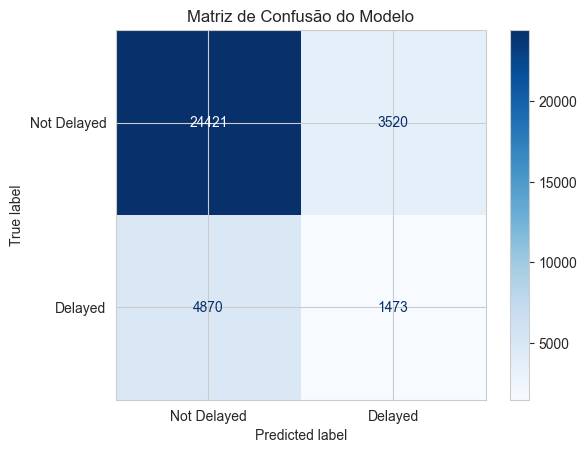

In [157]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Delayed', 'Delayed'])
disp.plot(cmap='Blues')

plt.title('Matriz de Confusão do Modelo')
plt.show()

C:\Users\Pedro\AppData\Local\Temp\ipykernel_10616\4062758199.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importancia', y='feature', data=importancias, palette='viridis')


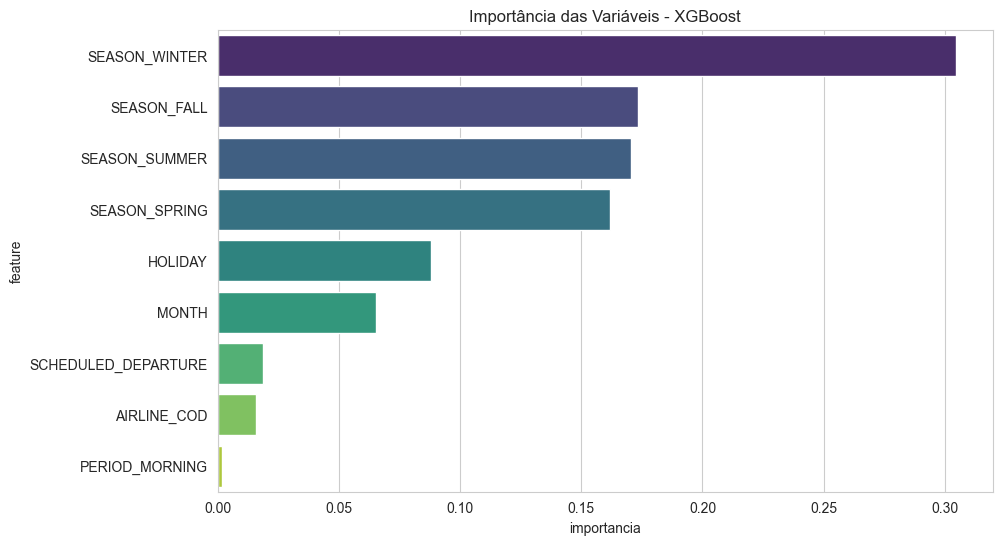

               feature  importancia
0        SEASON_WINTER     0.304399
1          SEASON_FALL     0.173394
2        SEASON_SUMMER     0.170472
3        SEASON_SPRING     0.161899
4              HOLIDAY     0.088204
5                MONTH     0.065264
7  SCHEDULED_DEPARTURE     0.018883
8          AIRLINE_COD     0.015728
6       PERIOD_MORNING     0.001758


In [158]:
# Pegando as importâncias do modelo treinado
importancias = pd.DataFrame({
    'feature': x_train.columns,
    'importancia': model_xgb.feature_importances_
}).sort_values(by='importancia', ascending=False)

# Plotando
plt.figure(figsize=(10, 6))
sns.barplot(x='importancia', y='feature', data=importancias, palette='viridis')
plt.title('Importância das Variáveis - XGBoost')
plt.show()

print(importancias)

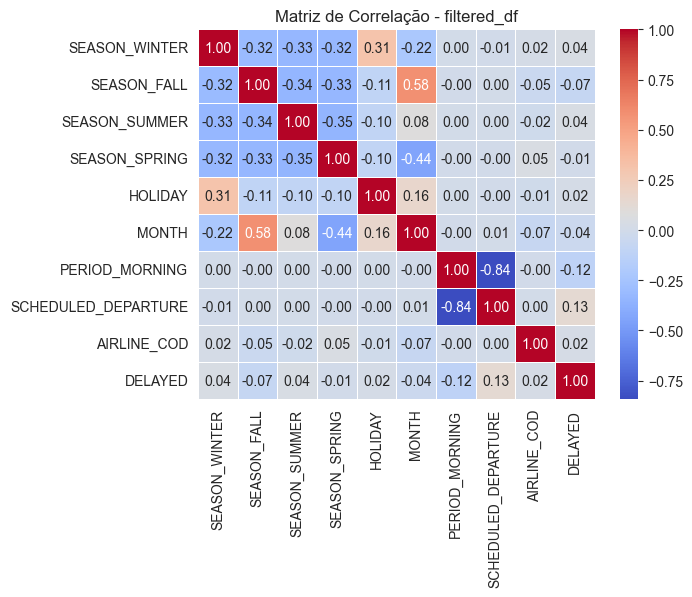

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculando a correlação entre as colunas do filtered_df
# O método .corr() calcula automaticamente a relação entre variáveis numéricas
corr_matrix = df_encoded.corr()

# 2. Criando o Heatmap
# annot=True: exibe os valores numéricos dentro dos quadrados
# cmap='coolwarm': define as cores (azul para negativo, vermelho para positivo)
# fmt=".2f": formata os números para 2 casas decimais
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Ajustes finais de título
plt.title('Matriz de Correlação - filtered_df')


# 4. Salvando o gráfico
plt.savefig('heatmap.png', bbox_inches='tight')

In [160]:
from sklearn.ensemble import RandomForestClassifier

# 1. Preparação com SMOTE (Mantendo sua lógica de usar apenas no treino)
# smote = SMOTE(random_state=42)
# x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

# print(f"Antes do SMOTE: {Counter(y_train)}")
# print(f"Depois do SMOTE: {Counter(y_train_smote)}")

# 2. Instanciando o Random Forest
# Mantendo hiperparâmetros comparáveis aos que você usou no XGBoost
model_rf = RandomForestClassifier(
    n_estimators=100,      # Mesmo número de árvores do seu XGBoost
    max_depth=5,           # Mesma profundidade para comparação justa
    random_state=42,
    n_jobs=-1              # Usa todos os núcleos do processador (similar ao speed do hist)
)

# 3. Treinamento
# Atribuindo os dados balanceados como você fez
x_train_final = x_train_smote
y_train_final = y_train_smote

model_rf.fit(x_train_final, y_train_final)

# 4. Predições e Avaliação
y_pred_rf = model_rf.predict(x_test)
y_proba_rf = model_rf.predict_proba(x_test)[:, 1]

print('\n\n')
print("--- Relatório de Classificação: Random Forest ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")




--- Relatório de Classificação: Random Forest ---
              precision    recall  f1-score   support

           0       0.85      0.74      0.79     27941
           1       0.26      0.42      0.32      6343

    accuracy                           0.68     34284
   macro avg       0.56      0.58      0.56     34284
weighted avg       0.74      0.68      0.70     34284

ROC-AUC Score: 0.6134


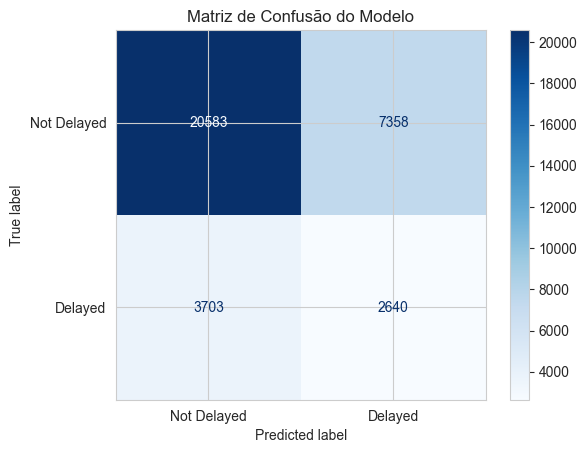

In [161]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Delayed', 'Delayed'])
disp.plot(cmap='Blues')

plt.title('Matriz de Confusão do Modelo')
plt.show()

In [143]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [144]:
# Agrupando por aeroporto de origem para calcular métricas
airport_stats = filtered_df.groupby('ORIGIN_AIRPORT').agg({
    'DELAYED': ['count', 'mean']  # Contagem total e proporção de atrasos
}).reset_index()

# Renomeando colunas para facilitar
airport_stats.columns = ['AIRPORT', 'TOTAL_FLIGHTS', 'DELAY_RATE']

# Normalização: Essencial para K-Means pois Volume e Taxa estão em escalas diferentes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(airport_stats[['TOTAL_FLIGHTS', 'DELAY_RATE']])

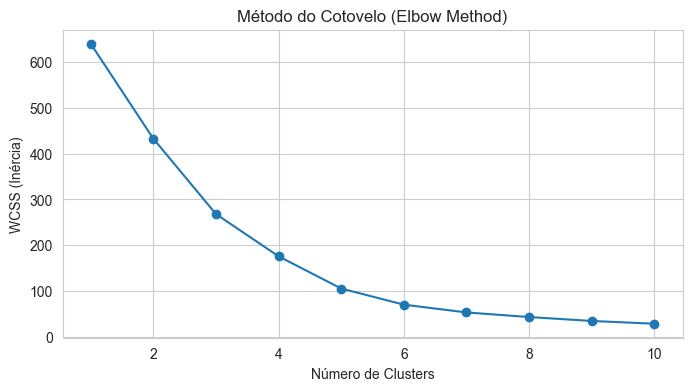

In [145]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS (Inércia)')
plt.show()

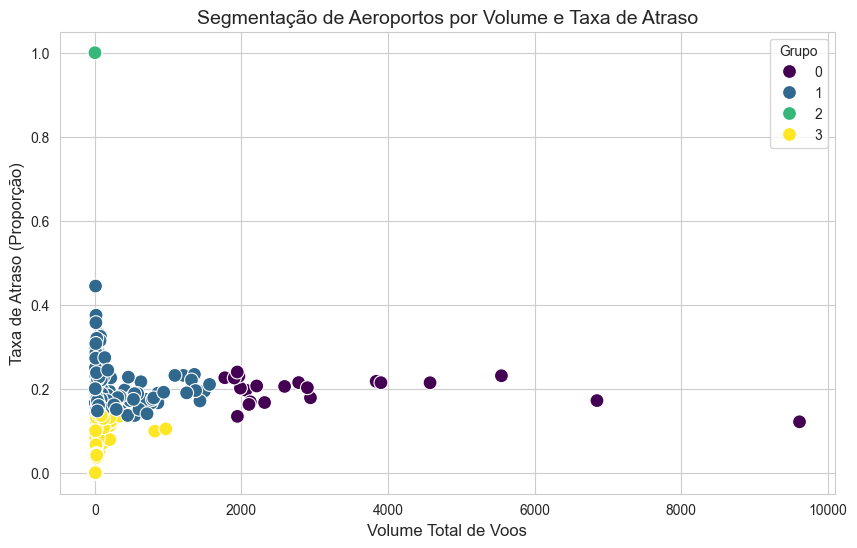

In [146]:
# Aplicando o K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
airport_stats['CLUSTER'] = kmeans.fit_predict(X_scaled)

# Visualização
plt.figure(figsize=(10, 6))
sns.scatterplot(data=airport_stats, x='TOTAL_FLIGHTS', y='DELAY_RATE', 
                hue='CLUSTER', palette='viridis', s=100)

plt.title('Segmentação de Aeroportos por Volume e Taxa de Atraso', fontsize=14)
plt.xlabel('Volume Total de Voos', fontsize=12)
plt.ylabel('Taxa de Atraso (Proporção)', fontsize=12)
plt.legend(title='Grupo')
plt.show()

In [165]:
cluster_n = 0
cluster = airport_stats[airport_stats['CLUSTER'] == cluster_n]['AIRPORT'].unique()
print(cluster)

<StringArray>
[   '', 'ATL', 'BOS', 'BWI', 'CLT', 'DEN', 'DFW', 'DTW', 'EWR', 'IAH', 'JFK',
 'LAS', 'LAX', 'LGA', 'MCO', 'MSP', 'ORD', 'PHX', 'SEA', 'SFO', 'SLC']
Length: 21, dtype: str


In [148]:
perfil_clusters = airport_stats.groupby('CLUSTER').agg({
    'TOTAL_FLIGHTS': 'mean',
    'DELAY_RATE': 'mean',
    'AIRPORT': 'count'
}).rename(columns={'AIRPORT': 'QUANTIDADE_AEROPORTOS'})

print(perfil_clusters)

         TOTAL_FLIGHTS  DELAY_RATE  QUANTIDADE_AEROPORTOS
CLUSTER                                                  
0          3231.809524    0.196655                     21
1           198.915423    0.206861                    201
2             1.000000    1.000000                      3
3            67.652632    0.073412                     95
